# Welcome to the OnSSET Notebook

This Jupyter based interface is built on the [OnSSET](http://www.onsset.org/) tool developed to provide an easy and quick way to generate electrification investment scenarios.

#### Start by importing the code 

In [8]:
from onsset import *
from IPython.display import display, Markdown, HTML
%matplotlib inline
%run funcs.ipynb
%run detailed_tech_parameters.ipynb
import warnings
import re
warnings.filterwarnings('ignore')
import time
import matplotlib.pylab as plt
import seaborn as sns
import tkinter as tk
from tkinter import filedialog, messagebox
root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

''

### 1. GIS data selection

First, run the cell below to browse to the directory your input CSV file is located at and select the input file. 

In [9]:
messagebox.showinfo('OnSSET', 'Open the input file with calibrated GIS data')
input_file = filedialog.askopenfilename()

onsseter = SettlementProcessor(input_file)
onsseter.conditioning()

Admin_1 is missing from the csv file. Filling with 0 values
MGDist is missing from the csv file. Filling with 0 values


In [10]:
### NEW (1) merge risk factors csv into onsseter.df and insert toggle to run with or without risk adjustments and standalone pv type

RUN_RISK = True   # True = use climate-risk penalties, False = baseline

SA_PV_RISK_MODE = "roof" # "ground" or "roof" - determines which risk factor to apply to SA_PV generation 

RISK_FILE = "clusters_climate_risk_factors_SLE.csv"

rf_cols = [
    "rf_total_MG_WIND_GENERATION",
    "rf_total_MG_PV_GENERATION",
    "rf_total_SA_PV",
    "rf_total_GRID_POLE",
    "rf_total_GRID_TRANSFORMER",
    "rf_total_GRID",
    "rf_total_MG_PV",
    "rf_total_MG_WIND"
]

if RUN_RISK:

    risk_factors = pd.read_csv(RISK_FILE)

    # Choose which standalone PV risk assumption to use
    if SA_PV_RISK_MODE == "ground":
        sa_pv_source_col = "rf_total_SA_PV_ground"
    elif SA_PV_RISK_MODE == "roof":
        sa_pv_source_col = "rf_total_SA_PV_roof"
    else:
        raise ValueError("SA_PV_RISK_MODE must be either 'ground' or 'roof'")

    # Create the generic column that onsset.py already uses
    risk_factors["rf_total_SA_PV"] = risk_factors[sa_pv_source_col]

    # Check all required columns exist
    missing_cols = [c for c in ["id"] + rf_cols if c not in risk_factors.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"Missing risk-factor columns: {missing_cols}")

    # Merge into OnSSET settlement dataframe
    onsseter.df = onsseter.df.merge(
        risk_factors[["id"] + rf_cols],
        on="id",
        how="left"
    )

    # Missing values become zero risk
    onsseter.df[rf_cols] = onsseter.df[rf_cols].fillna(0)

else:

    # Baseline/no-risk run: all risk factors are zero
    for col in rf_cols:
        onsseter.df[col] = 0

In [11]:
messagebox.showinfo('OnSSET', 'Open the file with hourly PV data')
pv_path = filedialog.askopenfilename()
messagebox.showinfo('OnSSET', 'Open the file with hourly Wind data')
wind_path = filedialog.askopenfilename()

In [12]:
messagebox.showinfo('OnSSET', 'Open the existing MV lines')
existing_mv = filedialog.askopenfilename()
x_mv_exist, y_mv_exist = onsseter.start_extension_points(existing_mv)
x_coordinates = x_mv_exist
y_coordinates = y_mv_exist

In [13]:
col_name = max(
    [c for c in onsseter.df.columns if c.startswith("FinalElecCode")],
    key=lambda x: int(re.search(r"\d{4}$", x).group())
)
existing_loc_x = np.array(onsseter.df.loc[onsseter.df[col_name] == 1, SET_X_DEG].tolist())
existing_loc_y = np.array(onsseter.df.loc[onsseter.df[col_name] == 1, SET_Y_DEG].tolist())

In [14]:
x_coordinates = np.append(x_mv_exist, existing_loc_x)
y_coordinates = np.append(y_mv_exist, existing_loc_y)

# 2. Modelling period and target electrification rate

Next, define the modelling period and the electrification rate to be achieved by the end of the analysis. Further down you will also define an intermediate year and target.

In [15]:
start_year = 2020  # This should be the same as in the calibration file
end_year = 2030

end_electrification_rate_target = 1 # E.g. 1 for 100% electrification rate or 0.80 for 80% electrification rate 

yearsofanalysis = [end_year]
eleclimits = {end_year: end_electrification_rate_target}
time_steps = {end_year: end_year-start_year}

In [16]:
start_elec_pop_col = f"ElecPop{start_year}"                                     ### NEW Ensure start-year elec pop column exists
start_final_code_col = f"FinalElecCode{start_year}"

if start_elec_pop_col not in onsseter.df.columns:
    onsseter.df[start_elec_pop_col] = onsseter.df["ElecPopCalib"].copy()
    onsseter.df.loc[onsseter.df[start_final_code_col] == 99, start_elec_pop_col] = 0

# 3. Enter country specific data

To run scenarios, the user can customize a large number of variables describing the social - economic - technological environment in the selected country. 

### a. Demographics and Social components

In [17]:
end_year_pop = 9719530          ### Write the expected population in the END year (e.g. 2030) 

urban_ratio_end_year = 0.48     ### Write the urban population population ratio in the END year (e.g. 2030)

num_people_per_hh_urban = 4.4     ### Write the number of people per household in urban areas
num_people_per_hh_rural = 5.2   ### Write the number of people per household in rural areas

### b. Technology specifications & costs

The cell below contains all the information that is used to calculate the levelized costs for all the technologies, including grid. These default values should be updated to reflect the most accurate values in the country. There are currently 5 technologies enabled in the model:
 * Grid
 * PV Hybrid Mini-grid
 * Wind Mini-grid
 * Hydro Mini-grid
 * PV Stand-alone systems

The key technology input parameters can be defined below. More detailed parameters for each technology can be found and edited in the **detailed_tech_parameters** notebook.

#### Centralized grid parameters 

In [18]:
grid_generation_cost = 0.069               ### This is the grid cost electricity USD/kWh as expected in the end year of the analysis
grid_power_plants_capital_cost = 2238      ### The cost in USD/kW is for capacity upgrades of the grid
grid_losses = 0.17                         ### The fraction of electricity lost in transmission and distribution (percentage)
grid_emission_factor = 745                 ### This is the average emissions from grid generation (gCO2/kWh), see e.g. https://unfccc.int/documents/461676

annual_new_grid_connections_limit = 999999999 # This is the maximum amount of new households that can be connected to the grid in one year
annual_grid_cap_gen_limit = 9999999        # This is the maximum generation capacity (MW) that can be added to the grid in one year

In [19]:
# Grid Transmission and distribution costs
hv_line_capacity=69 # kV
hv_line_cost=53000 # USD/km

grid_mv_line_capacity=33 # kV
grid_mv_line_cost=20000 # USD/km
grid_mv_line_max_length=100 # km
grid_MV_line_amperage_limit = 275  # Ampere (A)

grid_lv_line_capacity=0.4 #kV
grid_lv_line_max_length=1 # km
grid_lv_line_cost=15000 # USD/km

grid_service_Transf_type=75  # kVA
grid_service_Transf_cost=9000  # $/unit
grid_max_nodes_per_serv_trans=95  # maximum number of nodes served by each service (MV/LV) transformer

hv_mv_transformer_type = 16000 #kVA
hv_mv_transformer_cost = 25000 # USD/unit

#### Off-grid technology parameters

In [20]:
min_mg_size = 100             # Minimum number of households in a settlement for mini-grids to be considered
mg_min_grid_dist = 0          # Minimum distance from existing MV lines for mini-grids to be considered as an option

In [21]:
diesel_price = 1.43                    ### This is the diesel price in USD/liter as expected in the end year of the analysis

In [22]:
# PV and Wind hybrid mini-grid costs
pv_cost = 2950                      # PV panel costs including BoS (PV inverter, charge controller) (USD/kW)
battery_cost = 550                 # battery capital cost, USD/kWh of storage capacity                    
inverter_cost  = 598             # Battery inverter, USD/kW
diesel_gen_cost = 721              # diesel generator capital cost, USD/kW rated power
wind_cost = 3750                   # Wind turbine capital cost, USD/kW peak power

inverter_life=8    # Battery inverter expected lifetime in mini-grid, years
diesel_life=10      # diesel generator expected lifetime in mini-grid, years
pv_life=25          # PV panel expected lifetime in mini-grid, years
        
lpsp_max=0.02         # maximum loss of load allowed over the year, in share of kWh (e.g. 0.1 means that the mini-grid will be able to meet at least 90% of the demand over the year)
max_diesel = 0.0     # Maximum share of generation that can come from diesel generators (0-1). Set to 0 for fully renewable mini-grids

In [23]:
mg_hydro_capital_cost = {float("inf"): 3000}      ### Mini-grid Hydro capital cost (USD/kW) as expected in the years of the analysis

In [24]:
# Mini-grid distribution network spcification

mg_mv_line_capacity=33 # kV
mg_mv_line_cost = 25000 # USD/kW
mg_MV_line_amperage_limit = 275  # Ampere (A)

mg_lv_line_capacity=0.24 #kV
mg_lv_line_max_length=0.5 # km
mg_lv_line_cost=4250 # USD/km

mg_service_Transf_type=50  # kVA
mg_service_Transf_cost=4200  # $/unit
mg_max_nodes_per_serv_trans=300  # maximum number of nodes served by each service (MV/LV) transformer

In [25]:
sa_pv_capital_cost_1 = 9620          ### Solar Home System capital cost (USD/kW) for household systems under 20 W
sa_pv_capital_cost_2 = 8780          ### Solar Home System capital cost (USD/kW) for household systems between 21-50 W
sa_pv_capital_cost_3 = 6380           ### Solar Home System capital cost (USD/kW) for household systems between 51-100 W
sa_pv_capital_cost_4 = 4470           ### Solar Home System capital cost (USD/kW) for household systems between 101-1000 W
sa_pv_capital_cost_5 = 6950           ### Solar Home System capital cost (USD/kW) for household systems over 1 kW

shs_lifetime = 5                      ### Expected technology lifetime of Solar Home System

The cells below contain additional technology specifications

In [26]:
grid_discount_rate = 0.12 # E.g. 0.08 means a discount rate of 8%
mini_grid_discount_rate = 0.12
standalone_discount_rate = 0.12

### c. Electricity demand target

For the second lever, enter the target tier (level of electricity access) for urban and rural households respectively. This can take a value between "1" (lowest level of electricity access) and "5" (highest level of electricity access) as in ESMAPs Multi-Tier Framework for Measuring Electricity Access (found <a href="https://www.esmap.org/node/55526" target="_blank">here</a>). Alternatively, enter "6" to use a distribution of the tiers across the country based on poverty levels and GDP according to the methodology found <a href="https://www.mdpi.com/1996-1073/12/7/1395" target="_blank">here</a>.   

*On the GEP Explorer, the following three electricity demand targets are used:*

*Top down demand target - Low: In this case, all urban clusters are tergeted to reach the current average consumption level of electrified households, and rural settlements are assigned Tier 1.* 

*Top down demand target - High: In this case, all urban clusters are tergeted to reach one Tier higher than the current average consumption level of electrified households, and rural settlements are assigned Tier 3.*

*Bottom up demand target (Poverty - GDP): In this case each settlement is assigned a demand target based on poverty and GDP levels as described in the methodology above. Choose "6" for both the urban_target_tier and rural_target_tier to use this option* 

In [27]:
# Define the annual household electricity targets to choose from
tier_1 = 4.5  # 43 refers to kWh/household/year. 
tier_2 = 73
tier_3 = 365
tier_4 = 1250
tier_5 = 3000

In [28]:
rural_cutoff_size = 100  # Any rural settlement with fewer households is considered a "small rural" settlement, rural settlements with larger population is considered "large rural" 

urban_target_tier = 4               # Target demand Tier for Urban settlements
rural_target_tier_large = 2        # Target demand Tier for large rural settlements
rural_target_tier_small = 2         # Target demand Tier for small rural settlements

In [29]:
productive_demand = 1                     # 1 if productive demand is defined and should be included, else 0

### d. Rollout plan
This lever reflects the electrification approach to be examined. On the GEP Explorer, there are currently two options in use:

**Nationwide Least Cost approach:** This options aims to achieve the electrification rate targets set for the intermediate and end year. For the years where the target is set below 100%, the algorithm prioritizes grid densification first (ramp up in already electrified clusters) then selection based on lowest invetsment cost per capita to choose which clusters to be electrified.

**Forced grid approach:** Forced grid under a defined buffer zone (auto_intensification set equal to X km) & least cost approach outside of the buffer zone.

In [30]:
auto_intensification = 0        # Buffer distance (km) for automatic intensification

max_grid_intensification_cost = 1500  # Maximum cost per household (USD/household) for forced grid intensification 

If using a target access rate less than 100%, choose how to select which settlements to electrify first. The options are:
* 1 = Select the most easily reached settlements first, based on lowest distance to main roads
* 2 = Select the most easily reached settlements, based on travel time
* 3 = Select the largest settlements first
* 4 = Select settlements based on the lowest investment cost per capita (low demand settlements first)

In [31]:
prio_choice = 1       # Select 1, 2, 3 or 4 as described above 

# 4. Start a scenario run, which calculate and compare technology costs for every settlement in the country

Based on the previous calculation this piece of code identifies the LCoE that every off-grid technology can provide, for each single populated settlement of the selected country. The cell then takes all the currently grid-connected points in the country, and looks at the points within a certain distance from them, to see if it is more economical to connect them to the grid, or to use one of the off-grid technologies calculated above. Once more points are connected to the grid, the process is repeated, so that new points close to those points might also be connected. This is repeated until there are no new points to connect to the grid.

In [32]:
grid_calc, mg_pv_hybrid_calc, mg_wind_hybrid_calc, mg_hydro_calc, sa_pv_calc, sa_diesel_calc, mg_pv_hybrid_params, mg_wind_hybrid_params, mg_diesel_params, mg_interconnection, grid_reliability_option, cnse, grid_reliability = init_tech_info(grid_losses, grid_power_plants_capital_cost, grid_generation_cost, grid_discount_rate, grid_mv_line_capacity,
                   grid_MV_line_amperage_limit, grid_mv_line_cost, grid_lv_line_capacity, grid_lv_line_cost, grid_lv_line_max_length, 
                   grid_service_Transf_type, grid_service_Transf_cost, grid_max_nodes_per_serv_trans,
                   mini_grid_discount_rate, mg_mv_line_capacity, mg_MV_line_amperage_limit, mg_mv_line_cost, mg_lv_line_capacity, 
                   mg_lv_line_cost, mg_lv_line_max_length, mg_service_Transf_type, mg_service_Transf_cost, mg_max_nodes_per_serv_trans,
                   mg_hydro_capital_cost, shs_lifetime, standalone_discount_rate, sa_pv_capital_cost_1, sa_pv_capital_cost_2, sa_pv_capital_cost_3, 
                   sa_pv_capital_cost_4, sa_pv_capital_cost_5, min_mg_size, diesel_gen_cost, battery_cost, pv_life, diesel_life, inverter_cost,
                   inverter_life, lpsp_max, max_diesel, diesel_price)

onsseter.df, new_lines_geojson = run_scenario(onsseter, end_year_pop, urban_ratio_end_year, start_year, end_year, yearsofanalysis, x_coordinates, y_coordinates, tier_1, 
                 tier_2, tier_3, tier_4, tier_5, hv_line_capacity, hv_line_cost, hv_mv_transformer_cost, hv_mv_transformer_type, eleclimits, time_steps, 
                 annual_new_grid_connections_limit, annual_grid_cap_gen_limit, num_people_per_hh_urban, num_people_per_hh_rural, urban_target_tier, 
                 rural_target_tier_large, rural_target_tier_small, rural_cutoff_size, mg_diesel_params, mg_wind_hybrid_params, wind_path, 
                 mg_pv_hybrid_params, pv_path, mg_hydro_calc, mg_wind_hybrid_calc, sa_pv_calc, mg_pv_hybrid_calc, min_mg_size, mg_min_grid_dist,
                 grid_generation_cost, grid_calc, sa_diesel_calc, max_grid_intensification_cost, auto_intensification, grid_mv_line_max_length, 
                 mg_interconnection, grid_reliability_option, cnse, grid_reliability, prio_choice, grid_emission_factor)

finalize_results(onsseter, yearsofanalysis)

Starting Tue Jun 23 12:10:48 2026
Optimize Wind Hybrid Systems Tue Jun 23 12:10:48 2026
Optimize MG Hybrid Systems Tue Jun 23 12:10:53 2026
Calculate Off-Grid LCOEs Tue Jun 23 12:11:04 2026
Tue Jun 23 12:11:04 2026 Starting off-grid LCOE calculation for year 2030
Tue Jun 23 12:11:05 2026 Calculating off-grid investment cost for year 2030
Calculate Grid LCOEs Tue Jun 23 12:11:05 2026
Tue Jun 23 12:11:05 2026 Calculate grid extension for year 2030
771  new settlements connected to the grid Tue Jun 23 12:11:05 2026
151  new settlements connected to the grid Tue Jun 23 12:11:05 2026
54  new settlements connected to the grid Tue Jun 23 12:11:05 2026
13  new settlements connected to the grid Tue Jun 23 12:11:05 2026
2  new settlements connected to the grid Tue Jun 23 12:11:05 2026
Calculating results columns Tue Jun 23 12:11:05 2026
The electrification rate achieved in 2030 is 100.0 %



# 5. Results, Summaries and Visualization
With all the calculations and grid-extensions complete, this block gets the final results on which technology was chosen for each point, how much capacity needs to be installed and what it will cost. Then the summaries, plots and maps are generated.

In [33]:
techs = ["Grid", "SA_PV", "MG_PVHybrid", "MG_Wind", "MG_Hydro"]
tech_codes = [1, 3, 5, 6, 7]

summary_table, columns = calc_summary_table(onsseter.df, yearsofanalysis)
display(Markdown('### Summary \n These are the summarized results of the selected country'))
summary_table

### Summary 
 These are the summarized results of the selected country

,Population2030,NewConnections2030,Capacity2030 (MW),Investment2030 (million USD),Emissions2030 (tCO2)
Grid_dens,3853650,341122,116.44,412.05,315.32
Grid_ext,1948594,410262,67.78,536.25,180.26
SA_PV,2691727,611447,27.25,469.22,0.00
MG_PV_Hybrid,972534,221035,15.77,151.07,0.00
MG_Wind,0,0,0.00,0.00,0.00
MG_Hydro,253023,57506,2.57,31.54,0.00
Non-electrified,0,0,0.00,0.00,0.00
Total,9719528,1641372,229.81,1600.13,495.58


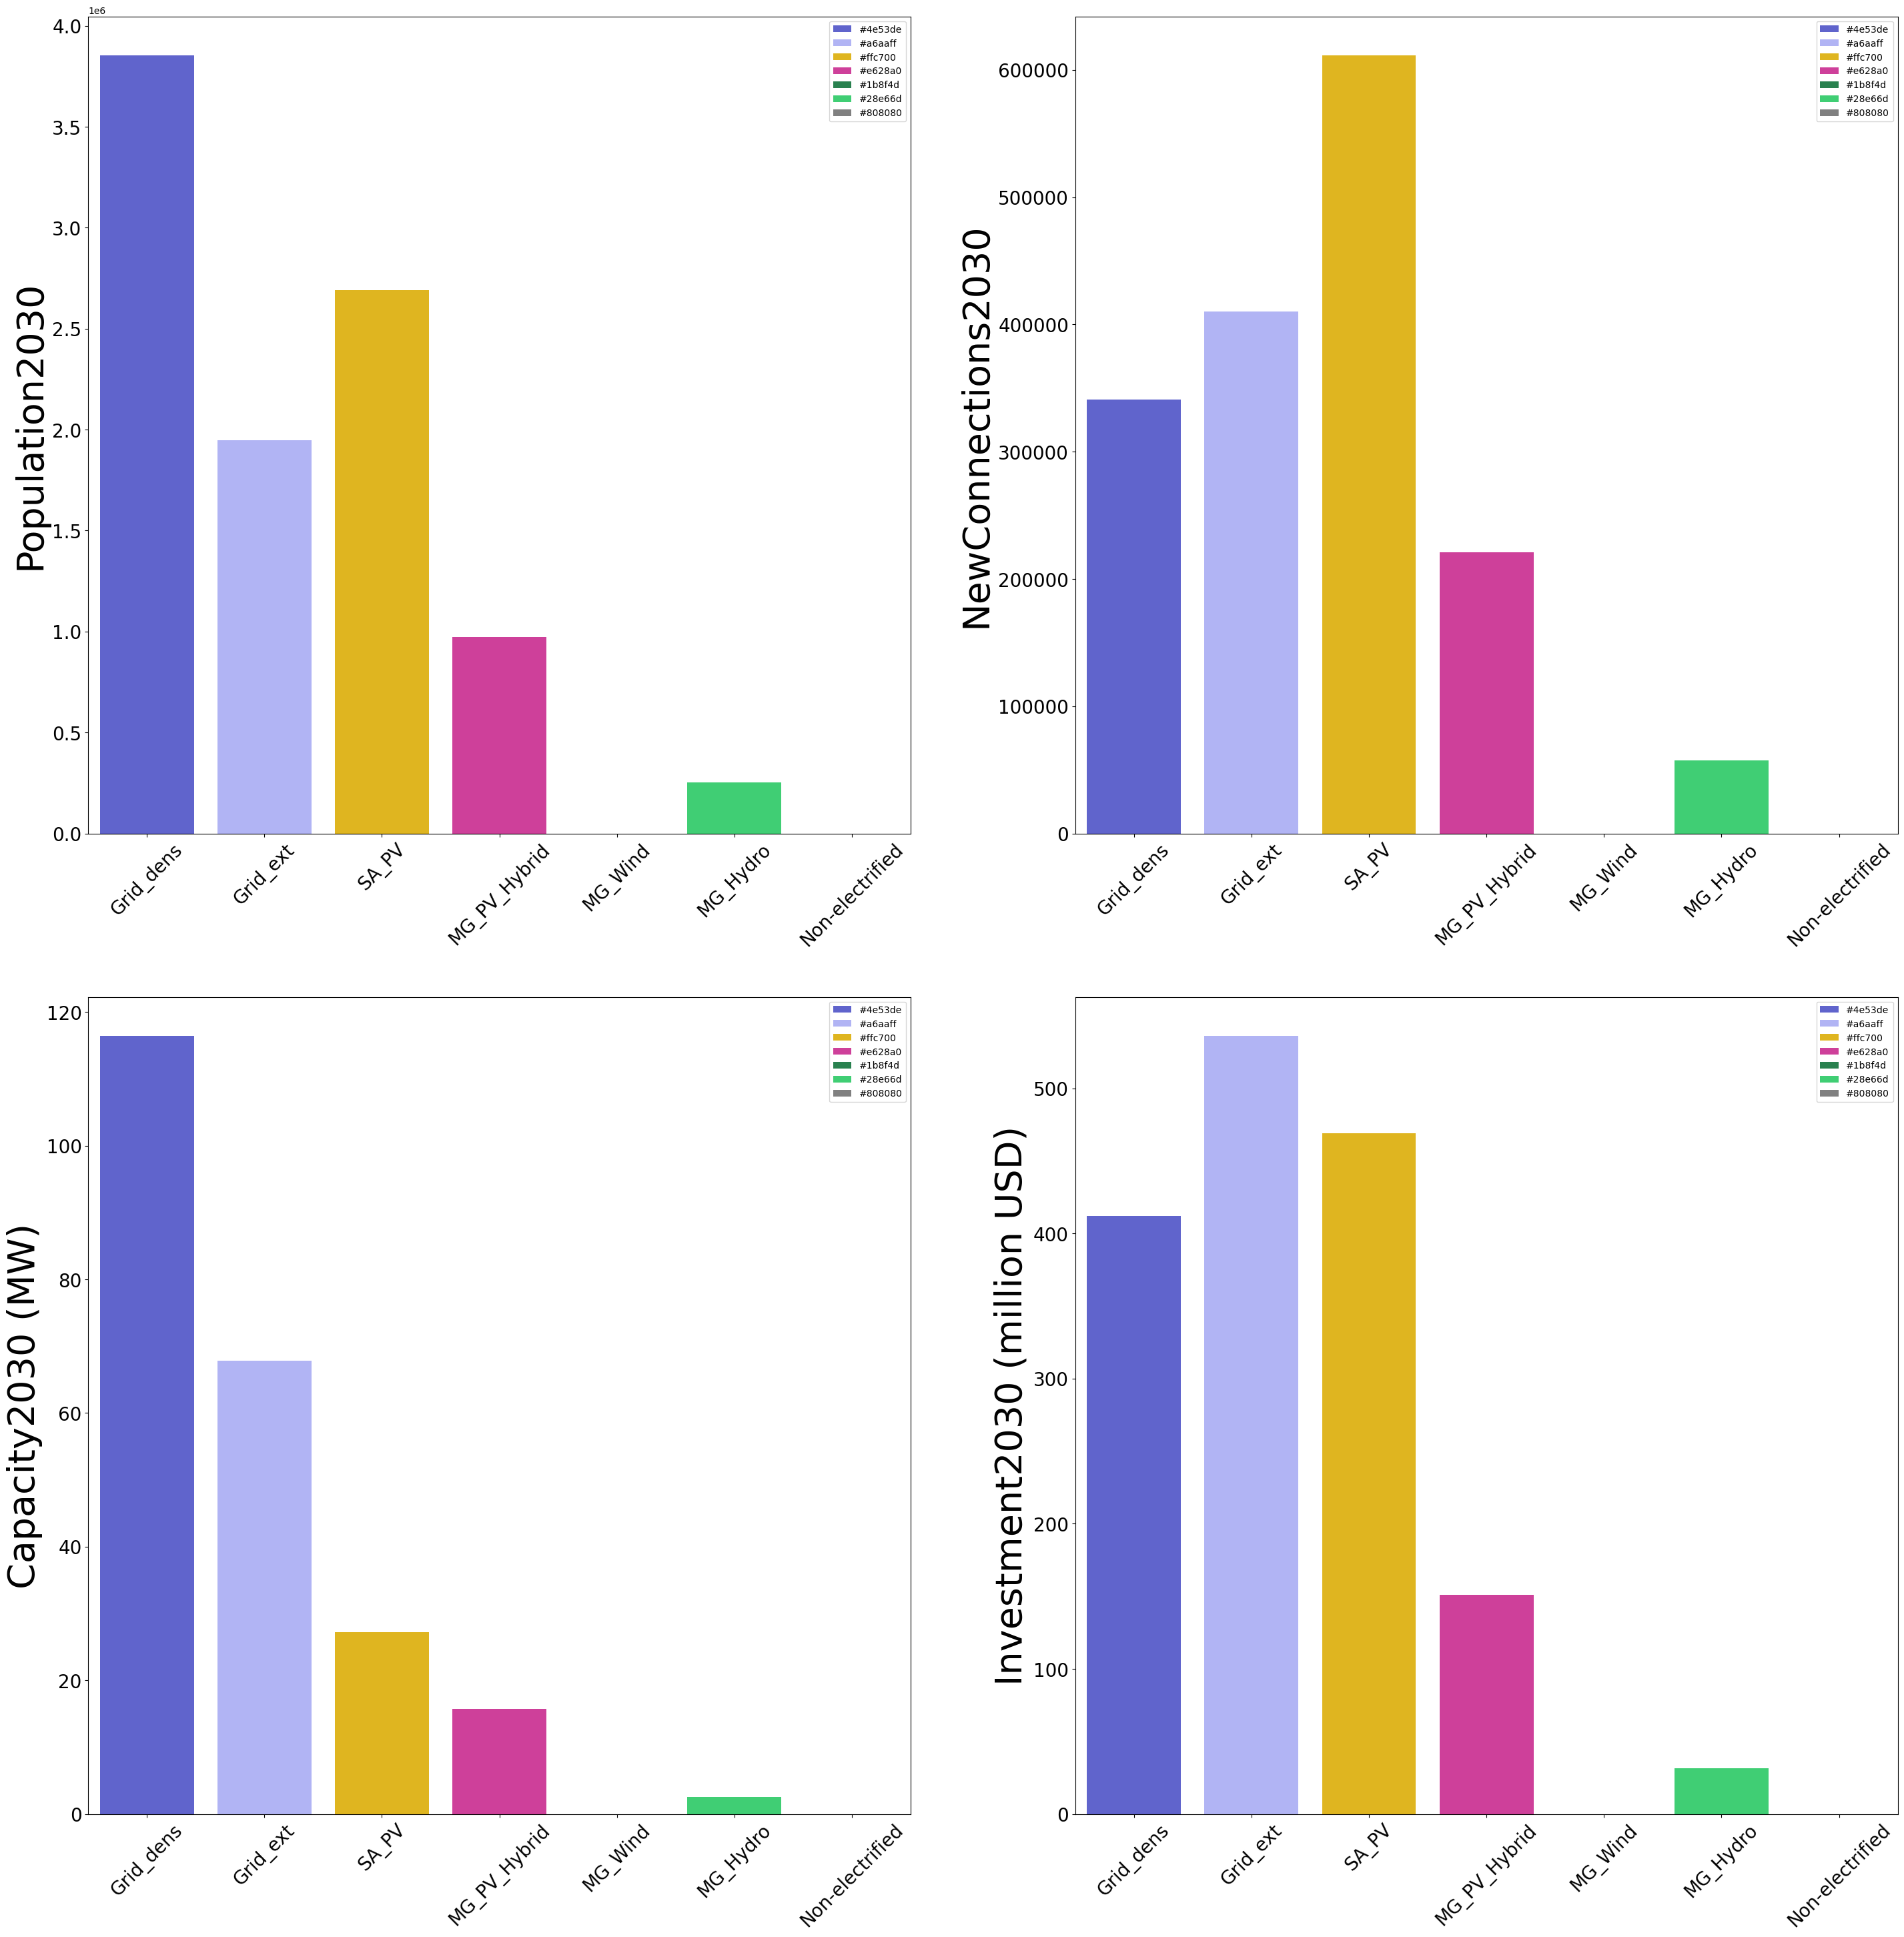

In [34]:
bar_plot(summary_table, columns, yearsofanalysis, techs)

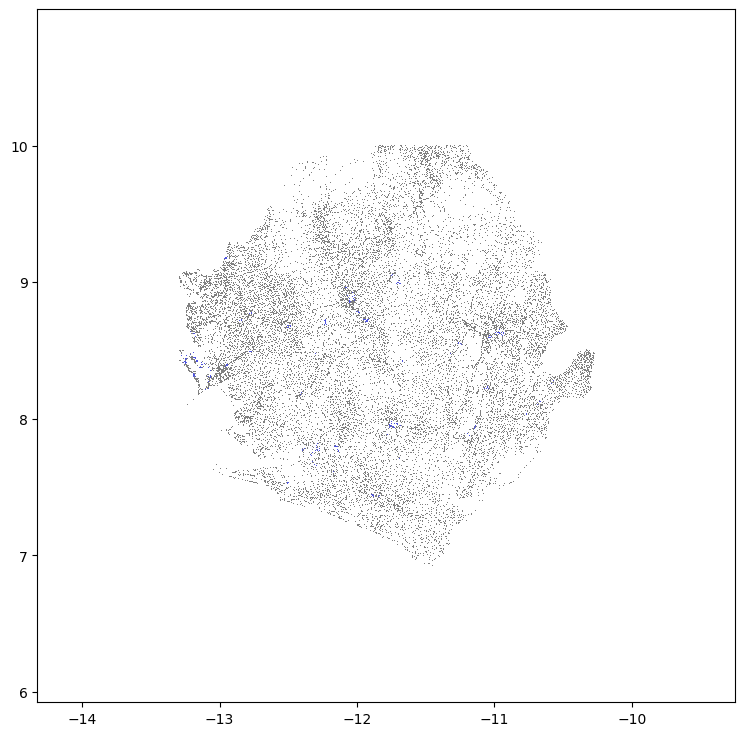

<Figure size 3000x3000 with 0 Axes>

Number of new PV Hybrid mini-grid locations:  0


In [35]:
map_plot(onsseter.df, start_year, start_year)                               ### NEW start year map

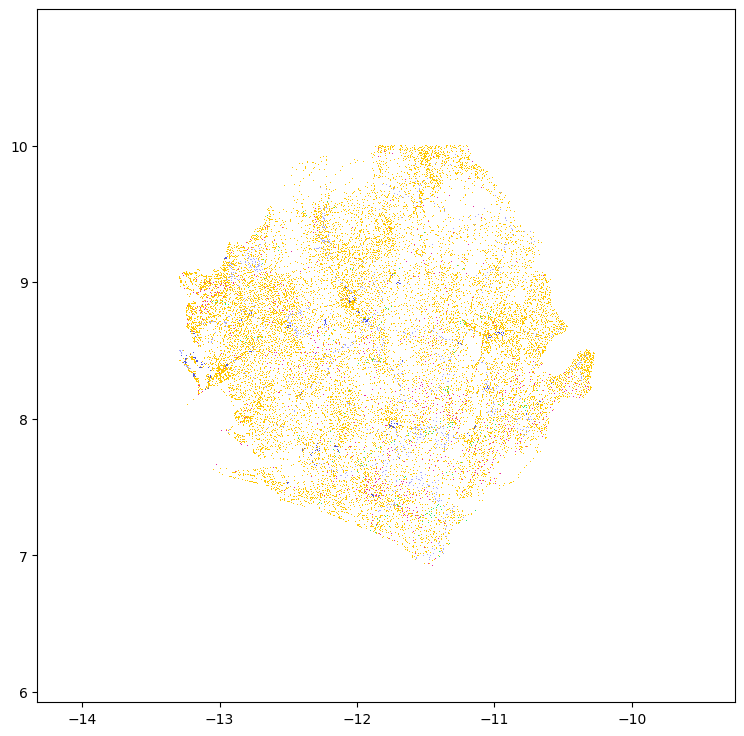

<Figure size 3000x3000 with 0 Axes>

Number of new PV Hybrid mini-grid locations:  677


In [36]:
map_plot(onsseter.df, end_year, start_year)

## 6. Exporting results

This code generates three csv files:
 - one containing all the results for the scenario created
 - one containing the summary for the scenario created
 - one containing some if the key input variables of the scenario

Before we proceed, please write the scenario_name in the first cell below. then move on to the next cell and run it to browse to the directory where you want to save your results. Sample file shall be located at .\ gep-onsset\sample_output. 

**Note that if you do not change the scenario name, the previous output files will be overwritten**

In [37]:
scenario_name = "SierraLeone"

In [38]:
messagebox.showinfo('OnSSET', 'Browse to the folder where you want to save the outputs')

output_dir = filedialog.askdirectory()
output_dir_variables = os.path.join(output_dir, '{}_Variables.csv'.format(scenario_name))
output_dir_results = os.path.join(output_dir, '{}_Results.csv'.format(scenario_name))
output_dir_summaries = os.path.join(output_dir, '{}_Summaries.csv'.format(scenario_name))

In [70]:
df_variables = save_variables(onsseter, start_year, end_year, end_electrification_rate_target, urban_target_tier, rural_target_tier_large,
                              rural_target_tier_small, auto_intensification, max_grid_intensification_cost, end_year_pop, urban_ratio_end_year,
                              grid_generation_cost, grid_power_plants_capital_cost, grid_losses, diesel_price, mg_hydro_capital_cost, min_mg_size,
                              mg_min_grid_dist, mg_interconnection, pv_cost, battery_cost, inverter_cost, diesel_gen_cost, max_diesel, 
                              sa_pv_capital_cost_1, sa_pv_capital_cost_2, sa_pv_capital_cost_3, sa_pv_capital_cost_4, sa_pv_capital_cost_5, 
                              grid_mv_line_cost, grid_lv_line_cost, grid_mv_line_capacity, grid_lv_line_capacity, grid_lv_line_max_length, hv_line_cost, 
                              grid_mv_line_max_length, annual_new_grid_connections_limit, annual_grid_cap_gen_limit, grid_discount_rate, 
                              mini_grid_discount_rate, standalone_discount_rate)

# Returning the summary as a csv file
summary_table.to_csv(output_dir_summaries, index=True)

# Returning the input variables as a csv file
df_variables.to_csv(output_dir_variables, index=False)

In [71]:
# Returning the result as a csv file
onsseter.df.to_csv(output_dir_results, float_format="%.4f", index=False)

In [72]:
# Saving the new MV lines as a geojson file

for year in yearsofanalysis:
    try:
        try:
            os.remove(os.path.join(output_dir, 'new_mv_lines_{}_{}.geojson'.format(scenario_name, year)))
        except FileNotFoundError:
            pass
        with open(os.path.join(output_dir, 'new_mv_lines_{}_{}.geojson'.format(scenario_name, year)), 'w') as f:
            geojson.dump(new_lines_geojson[year], f)
        gdf = gpd.read_file(os.path.join(output_dir, 'new_mv_lines_{}_{}.geojson'.format(scenario_name, year)))
        gdf = gdf.set_crs(3395, allow_override=True)
        gdf = gdf.to_crs(4326)
        gdf.to_file(os.path.join(output_dir, 'new_mv_lines_{}_{}.geojson'.format(scenario_name, year)))
    except Exception as e:
        print(year, e)

### Additional exports and comparisons between Risk and No Risk

In [73]:
if RUN_RISK:
    scenario_type = f"Risk_SAPV_{SA_PV_RISK_MODE}"
else:
    scenario_type = "NoRisk"

export_tag = f"{scenario_name}_{scenario_type}"

output_dir_variables = os.path.join(output_dir, f"{export_tag}_Variables.csv")
output_dir_results = os.path.join(output_dir, f"{export_tag}_Results.csv")
output_dir_summaries = os.path.join(output_dir, f"{export_tag}_Summaries.csv")

# Save variables
df_variables = save_variables(
    onsseter, start_year, end_year, end_electrification_rate_target,
    urban_target_tier, rural_target_tier_large, rural_target_tier_small,
    auto_intensification, max_grid_intensification_cost, end_year_pop,
    urban_ratio_end_year, grid_generation_cost, grid_power_plants_capital_cost,
    grid_losses, diesel_price, mg_hydro_capital_cost, min_mg_size,
    mg_min_grid_dist, mg_interconnection, pv_cost, battery_cost,
    inverter_cost, diesel_gen_cost, max_diesel,
    sa_pv_capital_cost_1, sa_pv_capital_cost_2, sa_pv_capital_cost_3,
    sa_pv_capital_cost_4, sa_pv_capital_cost_5,
    grid_mv_line_cost, grid_lv_line_cost, grid_mv_line_capacity,
    grid_lv_line_capacity, grid_lv_line_max_length, hv_line_cost,
    grid_mv_line_max_length, annual_new_grid_connections_limit,
    annual_grid_cap_gen_limit, grid_discount_rate,
    mini_grid_discount_rate, standalone_discount_rate
)

summary_table.to_csv(output_dir_summaries, index=True)
df_variables.to_csv(output_dir_variables, index=False)
onsseter.df.to_csv(output_dir_results, float_format="%.4f", index=False)

In [74]:
# Export summary bar plot
def export_summary_bar_plot(summary_table, columns, yearsofanalysis, techs, filename_base):
    import matplotlib.pyplot as plt
    import numpy as np

    summary_plot = summary_table.drop(labels="Total", axis=0).copy()

    # Use fixed colours matching the technology maps
    tech_colors = {
        "Grid": "#4e53de",
        "Grid_dens": "#4e53de",
        "Grid_ext": "#2c7fb8",
        "SA_PV": "#ffc700",
        "MG_PVHybrid": "#e628a0",
        "MG_PV_Hybrid": "#e628a0",
        "MG_Wind": "#1b8f4d",
        "MG_Hydro": "#28e66d",
        "Non-electrified": "#808080"
    }

    colors = [
        tech_colors.get(str(t), "#808080")
        for t in summary_plot.index
    ]

    # Pick the final-year columns
    if len(yearsofanalysis) == 1:
        plot_cols = columns[0:4]
    else:
        plot_cols = columns[-4:]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for ax, col in zip(axes, plot_cols):
        values = pd.to_numeric(summary_plot[col], errors="coerce").fillna(0)

        ax.bar(summary_plot.index.astype(str), values, color=colors)
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(f"Scenario summary: {export_tag}", fontsize=16)
    fig.tight_layout()

    fig.savefig(filename_base + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(filename_base + ".pdf", bbox_inches="tight")

    plt.close(fig)


export_summary_bar_plot(
    summary_table,
    columns,
    yearsofanalysis,
    techs,
    os.path.join(output_dir, f"{export_tag}_BarPlot")
)

In [75]:
# Export technology maps
def save_tech_map(df, year, filename):
    tech_labels = {
        1: "Grid",
        2: "Grid extension",
        3: "SA_PV",
        5: "MG_PVHybrid",
        6: "MG_Wind",
        7: "MG_Hydro",
        99: "Non-electrified"
    }

    tech_colors = {
        1: "#4e53de",   # Grid
        2: "#2c7fb8",   # Grid extension
        3: "#ffc700",   # SA_PV
        5: "#e628a0",   # MG_PVHybrid
        6: "#1b8f4d",   # MG_Wind
        7: "#28e66d",   # MG_Hydro
        99: "#808080"   # Non-electrified
    }

    code_col = f"FinalElecCode{year}"

    # Plot largest codes first, smallest codes last/on top
    plot_order = [99, 7, 6, 5, 3, 2, 1]

    fig, ax = plt.subplots(figsize=(8, 8))

    for code in plot_order:
        sub = df[df[code_col] == code]
        if len(sub) > 0:
            ax.scatter(
                sub["X_deg"],
                sub["Y_deg"],
                s=2,
                color=tech_colors[code],
                label=tech_labels[code]
            )

    ax.set_title(f"Technology assignment {year}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(markerscale=5, fontsize=8)
    ax.axis("equal")
    fig.tight_layout()

    fig.savefig(filename + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(filename + ".pdf", bbox_inches="tight")
    plt.close(fig)

save_tech_map(
    onsseter.df,
    start_year,
    os.path.join(output_dir, f"{export_tag}_TechMap_{start_year}")
)

save_tech_map(
    onsseter.df,
    end_year,
    os.path.join(output_dir, f"{export_tag}_TechMap_{end_year}")
)

### Baseline vs. Risk comparison (Only after running Risk = TRUE and FALSE)

In [81]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Choose which risk run to compare against baseline
COMPARE_SA_PV_RISK_MODE = "roof"

baseline_file = os.path.join(
    output_dir,
    f"{scenario_name}_NoRisk_Results.csv"
)

risk_file = os.path.join(
    output_dir,
    f"{scenario_name}_Risk_SAPV_{COMPARE_SA_PV_RISK_MODE}_Results.csv"
)

comparison_tag = f"{scenario_name}_Risk_SAPV_{COMPARE_SA_PV_RISK_MODE}"

print("Using baseline file:")
print(os.path.basename(baseline_file))

print("\nUsing risk file:")
print(os.path.basename(risk_file))

if not os.path.exists(baseline_file):
    raise FileNotFoundError(f"Missing baseline file: {baseline_file}")

if not os.path.exists(risk_file):
    raise FileNotFoundError(f"Missing risk file: {risk_file}")

baseline_df = pd.read_csv(baseline_file)
risk_df = pd.read_csv(risk_file)

Using baseline file:
SierraLeone_NoRisk_Results.csv

Using risk file:
SierraLeone_Risk_SAPV_roof_Results.csv


### Map: LCOE change

Show the LCOE change by settlement, even if technology is not reassigned

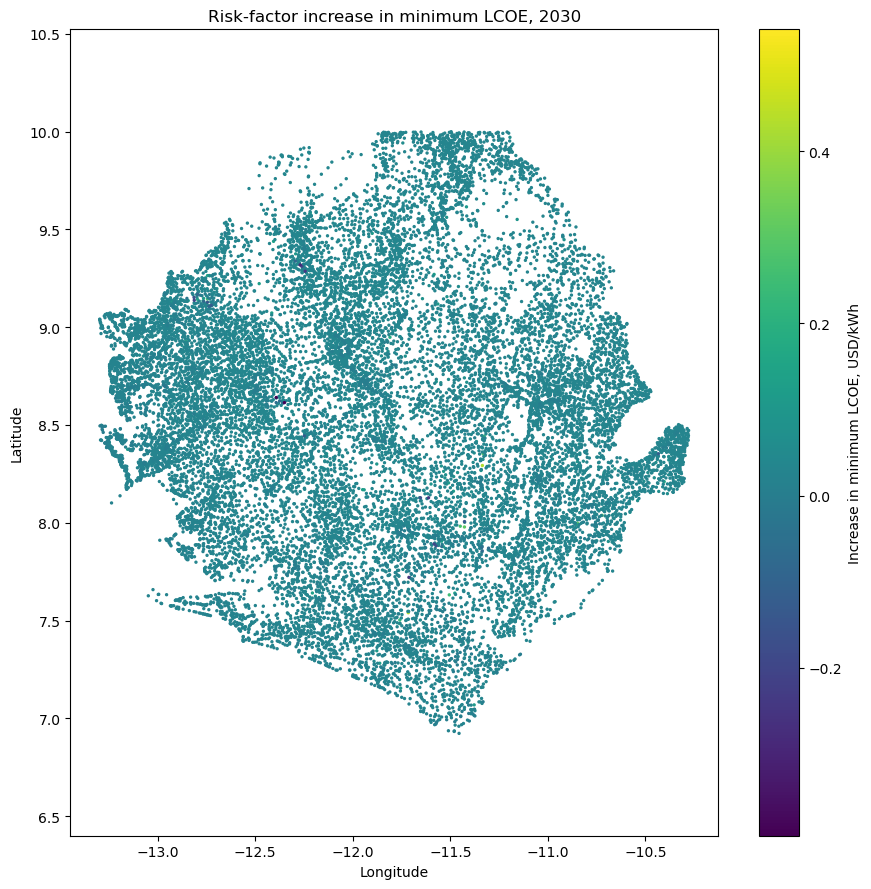

In [82]:
import matplotlib.pyplot as plt
import os
import numpy as np

lcoe_col = f"MinimumOverallLCOE{end_year}"

lcoe_change = baseline_df[["id", "X_deg", "Y_deg", lcoe_col]].merge(
    risk_df[["id", lcoe_col]],
    on="id",
    suffixes=("_baseline", "_risk")
)

lcoe_change["LCOE_change"] = (
    lcoe_change[f"{lcoe_col}_risk"] -
    lcoe_change[f"{lcoe_col}_baseline"]
)

# IMPORTANT:
# Plot largest changes first, smallest changes last/on top
lcoe_change_plot = lcoe_change.sort_values("LCOE_change", ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))

sc = ax.scatter(
    lcoe_change_plot["X_deg"],
    lcoe_change_plot["Y_deg"],
    c=lcoe_change_plot["LCOE_change"],
    s=2
)

plt.colorbar(sc, ax=ax, label="Increase in minimum LCOE, USD/kWh")

ax.set_title(f"Risk-factor increase in minimum LCOE, {end_year}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.axis("equal")

fig.tight_layout()

fig.savefig(
    os.path.join(output_dir, f"{comparison_tag}_LCOE_Change_Map_{end_year}.png"),
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(output_dir, f"{comparison_tag}_LCOE_Change_Map_{end_year}.pdf"),
    bbox_inches="tight"
)

plt.show()

## Colour-graded reassignment matrix

### Reassignment matrix: no risk vs risk

Assignment_Risk,Grid,SA_PV,MG_PVHybrid,MG_Wind,MG_Hydro
Assignment_NoRisk,,,,,
Grid,1178,35,3,0,1
SA_PV,33,18292,0,0,3
MG_PVHybrid,40,100,675,0,4
MG_Wind,0,0,0,0,0
MG_Hydro,0,0,0,0,184


Total settlements compared: 20548
Settlements reassigned: 219


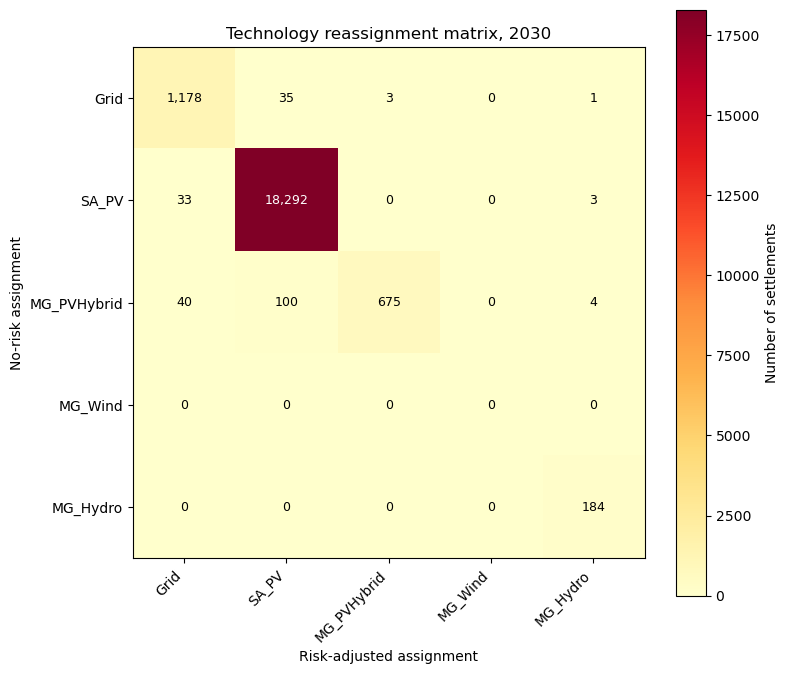

In [83]:
if True:

    # Technology LCOE columns used to infer final-year assignment
    tech_lcoe_cols = {
        "Grid": f"Grid{end_year}",
        "SA_PV": f"SA_PV{end_year}",
        "MG_PVHybrid": f"MG_PVHybrid{end_year}",
        "MG_Wind": f"MG_Wind{end_year}",
        "MG_Hydro": f"MG_Hydro{end_year}"
    }

    # Keep only technologies available in both files
    tech_lcoe_cols = {
        tech: col for tech, col in tech_lcoe_cols.items()
        if col in baseline_df.columns and col in risk_df.columns
    }

    tech_order = ["Grid", "SA_PV", "MG_PVHybrid", "MG_Wind", "MG_Hydro"]
    tech_order = [t for t in tech_order if t in tech_lcoe_cols.keys()]

    def infer_assignment_from_lcoe(df, label):
        lcoe = df[list(tech_lcoe_cols.values())].copy()
        lcoe = lcoe.apply(pd.to_numeric, errors="coerce")

        # Treat unavailable / placeholder values as missing
        lcoe = lcoe.replace([np.inf, -np.inf], np.nan)
        lcoe = lcoe.mask(lcoe >= 90)

        # Rename e.g. Grid2030 -> Grid
        reverse_map = {v: k for k, v in tech_lcoe_cols.items()}
        lcoe = lcoe.rename(columns=reverse_map)

        out = df[["id", "X_deg", "Y_deg"]].copy()

        if f"Pop{end_year}" in df.columns:
            out[f"Pop{end_year}"] = df[f"Pop{end_year}"]

        out[f"Assignment_{label}"] = lcoe.idxmin(axis=1)
        out[f"LCOE_{label}"] = lcoe.min(axis=1)

        return out

    baseline_assign = infer_assignment_from_lcoe(baseline_df, "NoRisk")
    risk_assign = infer_assignment_from_lcoe(risk_df, "Risk")

    reassignment_df = baseline_assign.merge(
        risk_assign,
        on=["id", "X_deg", "Y_deg"],
        how="inner"
    )

    reassignment_df["Changed"] = (
        reassignment_df["Assignment_NoRisk"] !=
        reassignment_df["Assignment_Risk"]
    )

    # Count-based reassignment matrix
    reassignment_matrix = pd.crosstab(
        reassignment_df["Assignment_NoRisk"],
        reassignment_df["Assignment_Risk"]
    ).reindex(index=tech_order, columns=tech_order, fill_value=0)

    display(Markdown("### Reassignment matrix: no risk vs risk"))
    display(reassignment_matrix)

    print("Total settlements compared:", len(reassignment_df))
    print("Settlements reassigned:", reassignment_df["Changed"].sum())

    if f"Pop{end_year}" in reassignment_df.columns:
        print(
            "Population in reassigned settlements:",
            reassignment_df.loc[reassignment_df["Changed"], f"Pop{end_year}"].sum()
        )

    # Save CSV outputs
    reassignment_df.to_csv(
        os.path.join(output_dir, f"{comparison_tag}_Reassignment_Details_{end_year}.csv"),
        index=False
    )

    reassignment_matrix.to_csv(
        os.path.join(output_dir, f"{comparison_tag}_Reassignment_Matrix_{end_year}.csv")
    )

    # Colour-graded heatmap image
    fig, ax = plt.subplots(figsize=(8, 7))

    matrix_values = reassignment_matrix.values

    im = ax.imshow(matrix_values, cmap="YlOrRd")

    ax.set_xticks(np.arange(len(reassignment_matrix.columns)))
    ax.set_yticks(np.arange(len(reassignment_matrix.index)))

    ax.set_xticklabels(reassignment_matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(reassignment_matrix.index)

    ax.set_xlabel("Risk-adjusted assignment")
    ax.set_ylabel("No-risk assignment")
    ax.set_title(f"Technology reassignment matrix, {end_year}")

    # Annotate cells
    max_value = matrix_values.max()

    for i in range(matrix_values.shape[0]):
        for j in range(matrix_values.shape[1]):
            value = matrix_values[i, j]

            if value == 0:
                text_colour = "black"
            elif value > max_value * 0.5:
                text_colour = "white"
            else:
                text_colour = "black"

            ax.text(
                j,
                i,
                f"{value:,}",
                ha="center",
                va="center",
                color=text_colour,
                fontsize=9
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Number of settlements")

    fig.tight_layout()

    fig.savefig(
        os.path.join(output_dir, f"{comparison_tag}_Reassignment_Matrix_{end_year}.png"),
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        os.path.join(output_dir, f"{comparison_tag}_Reassignment_Matrix_{end_year}.pdf"),
        bbox_inches="tight"
    )

    plt.show()

else:
    print("Reassignment matrix not created because RUN_RISK is False.")
    print("First export the NoRisk run, then run again with RUN_RISK=True.")

In [84]:
lcoe_col = f"MinimumOverallLCOE{end_year}"
code_col = f"FinalElecCode{end_year}"

lcoe_change = baseline_df[["id", "X_deg", "Y_deg", lcoe_col, code_col]].merge(
    risk_df[["id", lcoe_col, code_col]],
    on="id",
    suffixes=("_baseline", "_risk")
)

lcoe_change["LCOE_change"] = (
    lcoe_change[f"{lcoe_col}_risk"] -
    lcoe_change[f"{lcoe_col}_baseline"]
)

tech_labels = {
    1: "Grid / existing grid",
    2: "Grid extension",
    3: "SA_PV",
    5: "MG_PVHybrid",
    6: "MG_Wind",
    7: "MG_Hydro",
    99: "Non-electrified"
}

lcoe_change["Technology"] = lcoe_change[f"{code_col}_risk"].map(tech_labels)

print("Overall LCOE change summary, USD/kWh:")
display(lcoe_change["LCOE_change"].describe())

print("\nPercentiles, USD/kWh:")
display(lcoe_change["LCOE_change"].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1]))

print("\nMean LCOE change by final technology, USD/kWh:")
display(
    lcoe_change.groupby("Technology")["LCOE_change"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

Overall LCOE change summary, USD/kWh:


count    20548.000000
mean         0.030983
std          0.015009
min         -0.395200
25%          0.030300
50%          0.031900
75%          0.033300
max          0.541600
Name: LCOE_change, dtype: float64


Percentiles, USD/kWh:


0.00   -0.395200
0.01    0.000000
0.05    0.016100
0.25    0.030300
0.50    0.031900
0.75    0.033300
0.95    0.034900
0.99    0.067959
1.00    0.541600
Name: LCOE_change, dtype: float64


Mean LCOE change by final technology, USD/kWh:


,count,mean,median,min,max
Technology,,,,,
MG_PVHybrid,678,0.046404,0.03710,0.0182,0.4280
SA_PV,18427,0.031455,0.03200,0.0107,0.4301
Grid extension,991,0.021493,0.01060,-0.3952,0.5416
Grid / existing grid,264,0.014972,0.00215,0.0000,0.2506
MG_Hydro,188,0.001555,0.00000,0.0000,0.1255


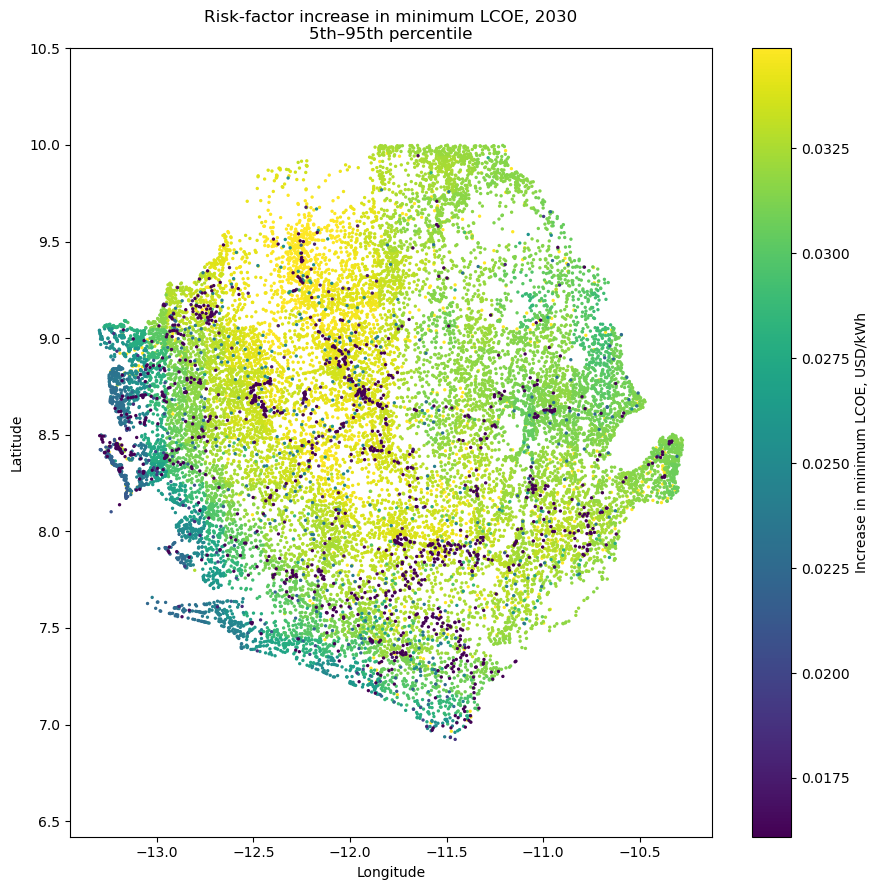

In [85]:
import matplotlib.pyplot as plt
import os

plot_df = lcoe_change.copy()

# Plot largest values first, smallest values last/on top
plot_df = plot_df.sort_values("LCOE_change", ascending=False)

vmin = plot_df["LCOE_change"].quantile(0.05)
vmax = plot_df["LCOE_change"].quantile(0.95)

fig, ax = plt.subplots(figsize=(9, 9))

sc = ax.scatter(
    plot_df["X_deg"],
    plot_df["Y_deg"],
    c=plot_df["LCOE_change"],
    s=2,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Increase in minimum LCOE, USD/kWh")

ax.set_title(f"Risk-factor increase in minimum LCOE, {end_year}\n5th–95th percentile")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.axis("equal")

fig.tight_layout()

fig.savefig(
    os.path.join(output_dir, f"{comparison_tag}_LCOE_Change_Map_q0595_{end_year}.png"),
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(output_dir, f"{comparison_tag}_LCOE_Change_Map_q0595_{end_year}.pdf"),
    bbox_inches="tight"
)

plt.show()

# Final summary table

In [39]:
import os
import pandas as pd
import numpy as np
from IPython.display import display

# File paths

baseline_file = os.path.join(output_dir, f"{scenario_name}_NoRisk_Results.csv")
ground_file   = os.path.join(output_dir, f"{scenario_name}_Risk_SAPV_ground_Results.csv")
roof_file     = os.path.join(output_dir, f"{scenario_name}_Risk_SAPV_roof_Results.csv")

baseline_df = pd.read_csv(baseline_file)
ground_df   = pd.read_csv(ground_file)
roof_df     = pd.read_csv(roof_file)


# Key columns

lcoe_col = f"MinimumOverallLCOE{end_year}"

# Population column: use Pop2030 if present, otherwise try to infer
if f"Pop{end_year}" in baseline_df.columns:
    pop_col = f"Pop{end_year}"
elif "Pop" in baseline_df.columns:
    pop_col = "Pop"
else:
    pop_candidates = [c for c in baseline_df.columns if "pop" in c.lower()]
    pop_col = pop_candidates[0]
    print(f"Using inferred population column: {pop_col}")

# Technology columns used to infer least-cost technology
tech_lcoe_cols = {
    "Grid": f"Grid{end_year}",
    "SA_PV": f"SA_PV{end_year}",
    "MG_PVHybrid": f"MG_PVHybrid{end_year}",
    "MG_Wind": f"MG_Wind{end_year}",
    "MG_Hydro": f"MG_Hydro{end_year}",
}

tech_lcoe_cols = {
    tech: col for tech, col in tech_lcoe_cols.items()
    if col in baseline_df.columns
}

def infer_tech(df):
    """Infer selected technology from minimum LCOE columns."""
    return df[list(tech_lcoe_cols.values())].idxmin(axis=1).map(
        {v: k for k, v in tech_lcoe_cols.items()}
    )

baseline_df["_tech"] = infer_tech(baseline_df)
ground_df["_tech"]   = infer_tech(ground_df)
roof_df["_tech"]     = infer_tech(roof_df)


# Summary function

def compare_runs(base_df, risk_df, label, percent_base_label="baseline"):
    
    comp = base_df[["id", pop_col, lcoe_col, "_tech"]].merge(
        risk_df[["id", lcoe_col, "_tech"]],
        on="id",
        suffixes=("_base", "_risk")
    )
    
    comp["tech_changed"] = comp["_tech_base"] != comp["_tech_risk"]
    comp["lcoe_change"] = comp[f"{lcoe_col}_risk"] - comp[f"{lcoe_col}_base"]
    comp["lcoe_change_pct"] = (
        comp["lcoe_change"] / comp[f"{lcoe_col}_base"]
    ) * 100
    
    changed = comp[comp["tech_changed"]].copy()
    
    # Reassignment flows
    flows = (
        changed
        .groupby(["_tech_base", "_tech_risk"])
        .size()
        .sort_values(ascending=False)
    )
    
    top_flows = "; ".join(
        [f"{a}→{b}: {n}" for (a, b), n in flows.head(5).items()]
    )
    
    row = {
        "Comparison": label,
        "Settlements": len(comp),
        "Changed settlements": int(comp["tech_changed"].sum()),
        "Changed settlements (%)": 100 * comp["tech_changed"].mean(),
        "Population affected": changed[pop_col].sum(),
        "Population affected (%)": 100 * changed[pop_col].sum() / comp[pop_col].sum(),
        f"Mean LCOE, {percent_base_label} (USD/kWh)": comp[f"{lcoe_col}_base"].mean(),
        "Mean LCOE, risk/adaptation (USD/kWh)": comp[f"{lcoe_col}_risk"].mean(),
        "Mean LCOE change (USD/kWh)": comp["lcoe_change"].mean(),
        "Mean LCOE change (%)": (
            (comp[f"{lcoe_col}_risk"].mean() - comp[f"{lcoe_col}_base"].mean())
            / comp[f"{lcoe_col}_base"].mean()
        ) * 100,
        "Median LCOE change (USD/kWh)": comp["lcoe_change"].median(),
        "LCOE change p5 (USD/kWh)": comp["lcoe_change"].quantile(0.05),
        "LCOE change p95 (USD/kWh)": comp["lcoe_change"].quantile(0.95),
        "Top reassignment flows": top_flows
    }
    
    return row, comp

# Build summary table

ground_row, ground_comp = compare_runs(
    baseline_df, ground_df,
    "Ground-risk vs no-risk baseline",
    percent_base_label="baseline"
)

roof_row, roof_comp = compare_runs(
    baseline_df, roof_df,
    "Roof-risk vs no-risk baseline",
    percent_base_label="baseline"
)

roof_vs_ground_row, roof_vs_ground_comp = compare_runs(
    ground_df, roof_df,
    "Roof-risk vs ground-risk",
    percent_base_label="ground-risk"
)

summary_table = pd.DataFrame([
    ground_row,
    roof_row,
    roof_vs_ground_row
])

# Formatting for display

formatted = summary_table.copy()

round_cols = [
    "Changed settlements (%)",
    "Population affected (%)",
    "Mean LCOE, baseline (USD/kWh)",
    "Mean LCOE, ground-risk (USD/kWh)",
    "Mean LCOE, risk/adaptation (USD/kWh)",
    "Mean LCOE change (USD/kWh)",
    "Mean LCOE change (%)",
    "Median LCOE change (USD/kWh)",
    "LCOE change p5 (USD/kWh)",
    "LCOE change p95 (USD/kWh)",
]

for col in formatted.columns:
    if "USD/kWh" in col:
        formatted[col] = formatted[col].round(4)
    elif "(%)" in col:
        formatted[col] = formatted[col].round(2)

formatted["Population affected"] = formatted["Population affected"].round(0).astype(int)

display(formatted)

# Export
summary_out = os.path.join(output_dir, f"{scenario_name}_Ground_Roof_Risk_Comparison_Summary.csv")
summary_table.to_csv(summary_out, index=False)

print("Saved summary table to:")
print(summary_out)

,Comparison,Settlements,Changed settlements,Changed settlements (%),Population affected,Population affected (%),"Mean LCOE, baseline (USD/kWh)","Mean LCOE, risk/adaptation (USD/kWh)",Mean LCOE change (USD/kWh),Mean LCOE change (%),Median LCOE change (USD/kWh),LCOE change p5 (USD/kWh),LCOE change p95 (USD/kWh),Top reassignment flows,"Mean LCOE, ground-risk (USD/kWh)"
0,Ground-risk vs no-risk baseline,20548,158,0.77,145509,1.50,1.5004,1.5555,0.0552,3.68,0.0410,0.0167,0.1382,SA_PV→Grid: 63; MG_PVHybrid→Grid: 47; MG_PVHyb...,NaN
1,Roof-risk vs no-risk baseline,20548,219,1.07,212699,2.19,1.5004,1.5314,0.0310,2.06,0.0319,0.0161,0.0349,MG_PVHybrid→SA_PV: 100; MG_PVHybrid→Grid: 40; ...,NaN
2,Roof-risk vs ground-risk,20548,134,0.65,113840,1.17,NaN,1.5314,-0.0242,-1.55,-0.0049,-0.1034,0.0000,Grid→SA_PV: 64; MG_PVHybrid→SA_PV: 63; Grid→MG...,1.5555


Saved summary table to:
/Users/adshead/Documents/onsset-original/Test-ouputs/SierraLeone_Ground_Roof_Risk_Comparison_Summary.csv
